In [1]:
import math
from pathlib import Path

import torch
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torchvision import transforms

In [2]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
LABELS_PATH = DATA_DIR / "labels.csv"

df = pd.read_csv(LABELS_PATH)

print("Dataset size:", len(df))
df.head()

Dataset size: 20000


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second,style_name
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,23,30,56,classic_light
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,17,12,0,minimal_blue
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,4,46,58,classic_light
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,18,43,26,clean_white
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,16,39,52,classic_light


In [3]:
def draw_hand(draw, center, angle_rad, length, color, width):
    cx, cy = center

    x = cx + length * math.cos(angle_rad)
    y = cy + length * math.sin(angle_rad)

    draw.line([cx, cy, x, y], fill=color, width=width)


def draw_hands_on_image(clean_image, hour, minute, second):
    img = clean_image.copy()
    draw = ImageDraw.Draw(img)

    width, height = img.size
    cx, cy = width / 2, height / 2
    radius = min(width, height) / 2 - max(5, width // 25)

    # 0 degrees should point to 12 o'clock, so we subtract 90 degrees
    hour_angle = math.radians((hour % 12) * 30 + minute * 0.5 - 90)
    minute_angle = math.radians(minute * 6 + second * 0.1 - 90)
    second_angle = math.radians(second * 6 - 90)

    draw_hand(draw, (cx, cy), hour_angle, radius * 0.50, (30, 30, 30), max(3, int(width * 0.04)))
    draw_hand(draw, (cx, cy), minute_angle, radius * 0.75, (30, 30, 30), max(2, int(width * 0.025)))
    draw_hand(draw, (cx, cy), second_angle, radius * 0.85, (200, 40, 40), max(1, int(width * 0.008)))

    cap_radius = max(3, width // 40)
    draw.ellipse(
        [cx - cap_radius, cy - cap_radius, cx + cap_radius, cy + cap_radius],
        fill=(30, 30, 30)
    )

    return img

In [4]:
def draw_hands_on_tensor(clean_batch, h_batch, m_batch, s_batch):
    """
    clean_batch: Tensor shape (B, 3, H, W), values in [0, 1]
    h_batch, m_batch, s_batch: Tensor shape (B,)
    returns: Tensor shape (B, 3, H, W), values in [0, 1]
    """
    outputs = []

    for i in range(clean_batch.shape[0]):
        clean_tensor = clean_batch[i].detach().cpu().clamp(0, 1)

        np_img = (clean_tensor.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(np_img)

        hour = int(h_batch[i].item())
        minute = int(m_batch[i].item())
        second = int(s_batch[i].item())

        out_img = draw_hands_on_image(pil_img, hour, minute, second)

        out_tensor = torch.from_numpy(
            np.array(out_img).astype("float32") / 255.0
        ).permute(2, 0, 1)

        outputs.append(out_tensor)

    return torch.stack(outputs)

Time: 10:46:55
Style: dark_mode


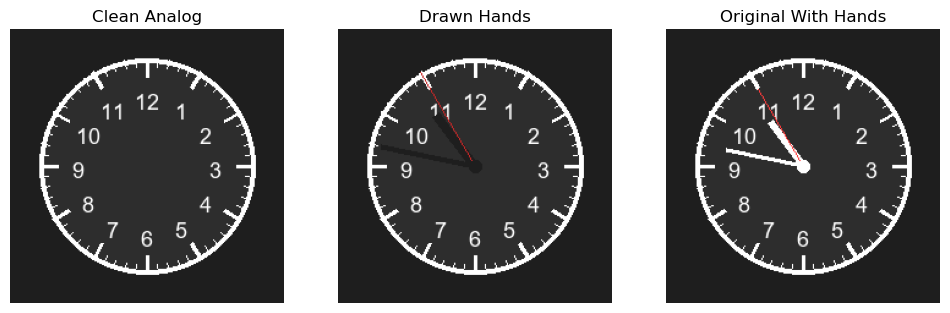

In [5]:
sample = df.sample(1).iloc[0]

clean_image = Image.open(sample["analog_clean_path"]).convert("RGB")
analog_with_hands = Image.open(sample["analog_with_hands_path"]).convert("RGB")

hour = int(sample["hour"])
minute = int(sample["minute"])
second = int(sample["second"])

generated = draw_hands_on_image(clean_image, hour, minute, second)

print(f"Time: {hour:02d}:{minute:02d}:{second:02d}")
print("Style:", sample["style_name"] if "style_name" in sample else "unknown")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(clean_image)
plt.title("Clean Analog")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(generated)
plt.title("Drawn Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_with_hands)
plt.title("Original With Hands")
plt.axis("off")

plt.show()